In [13]:
from gsnn.proc.coarsen import diff_io_equivalence
import torch 
import networkx as nx 
from gsnn.simulate.nx2pyg import pyg2nx

from sklearn.decomposition import PCA

from matplotlib import pyplot as plt 
import umap

%load_ext autoreload
%autoreload 2

/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
data = torch.load(f'../../workflow_outputs/lincs-gsnn/default/bionetwork/bionetwork.pt', weights_only=False)

In [25]:
G = pyg2nx(data)

scores = diff_io_equivalence(G, input_nodes=data.node_names_dict['input'], 
                                function_nodes=data.node_names_dict['function'],
                                output_nodes=data.node_names_dict['output'],
                                iters=10)



In [26]:
scores.shape

(2828, 1943)

In [27]:
scores

array([[7.0186346e-05, 6.6273489e-05, 7.0779010e-05, ..., 2.1588238e-07,
        1.4308988e-07, 1.5078125e-07],
       [4.7276913e-05, 3.6528640e-05, 4.6654219e-05, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.5963903e-03, 1.5265699e-03, 1.6161723e-03, ..., 3.8098857e-05,
        2.4942314e-05, 2.6287948e-05],
       ...,
       [2.0544359e-04, 1.9719891e-04, 2.0690300e-04, ..., 2.6682292e-06,
        1.7630479e-06, 1.8564616e-06],
       [3.8682365e-06, 3.8391613e-06, 3.8699836e-06, ..., 6.2325471e-06,
        4.0947270e-06, 4.3285686e-06],
       [1.6143716e-04, 1.2296950e-04, 1.4941144e-04, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], shape=(2828, 1943), dtype=float32)

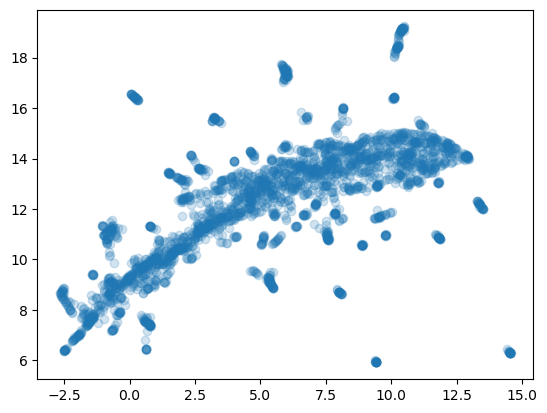

In [ ]:
#reducer = PCA(n_components=2)
reducer = umap.UMAP(n_components=2)
u = reducer.fit_transform(scores)

plt.figure() 
plt.scatter(u[:, 0], u[:, 1], alpha=0.2)
plt.show()

In [32]:
from sklearn.metrics import pairwise_distances
import numpy as np 


In [30]:
dist_mat = pairwise_distances(scores)

In [31]:
dist_mat.shape

(2828, 2828)

In [33]:
# select only the upper triangle 
d = dist_mat[np.triu_indices(dist_mat.shape[0], k=1)]

In [34]:
d.shape

(3997378,)

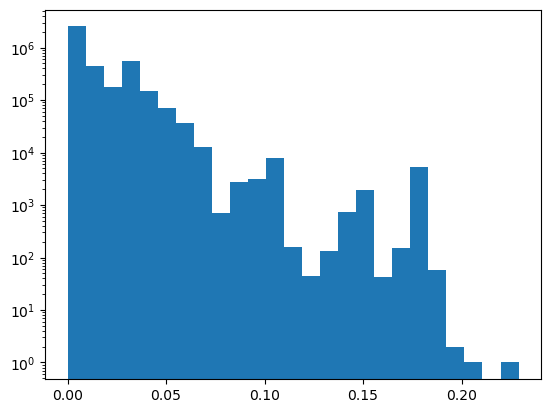

In [40]:
plt.figure()
plt.hist(d, bins=25)
plt.yscale('log')
plt.show() 

In [42]:
N_zero = (d == 0).sum()
N_nonzero = (d != 0).sum()

print(f'# zero: {N_zero} [p: {N_zero / (N_zero + N_nonzero):.2f}], # nonzero: {N_nonzero} [p: {N_nonzero / (N_zero + N_nonzero):.2f}]')

# zero: 9 [p: 0.00], # nonzero: 3997369 [p: 1.00]
